#### Weeks 9 & 10 Assignment - TSA Complaints
#### Author: Nicholas Stirling
#### Due Date: 3/1/26
#### Description: For this exercise you will be analyzing TSA complaint data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dim_airports = pd.read_csv("iata-icao.csv")
fact_airport = pd.read_csv("complaints-by-airport.csv")
fact_category = pd.read_csv("complaints-by-category.csv")
fact_subcategory = pd.read_csv("complaints-by-subcategory.csv")

# STANDARDIZE COLUMN NAMES

dim_airports.columns = dim_airports.columns.str.lower()
fact_airport.columns = fact_airport.columns.str.lower()
fact_category.columns = fact_category.columns.str.lower()
fact_subcategory.columns = fact_subcategory.columns.str.lower()

In [2]:
# CLEAN DIMENSION TABLE
dim_airports["iata"] = dim_airports["iata"].str.upper()

dim_airports = dim_airports.rename(columns={
    "airport": "airport_name"
})

dim_airports = dim_airports[
    ["iata", "airport_name", "country_code", "region_name", "latitude", "longitude"]
]

# CLEAN FACT TABLES
def clean_fact(df):
    df["airport"] = df["airport"].str.upper()
    df["year_month"] = pd.to_datetime(df["year_month"], errors="coerce")
    df = df.dropna(subset=["year_month"])
    df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0)
    return df

fact_airport = clean_fact(fact_airport)
fact_category = clean_fact(fact_category)
fact_subcategory = clean_fact(fact_subcategory)

# VALIDATE JOIN KEYS
missing = set(fact_airport["airport"]) - set(dim_airports["iata"])
if missing:
    print("Missing IATA codes in dimension table:", missing)

# MERGE FACT TABLES
fact_airport = fact_airport.merge(
    dim_airports,
    left_on="airport",
    right_on="iata",
    how="left"
)

fact_category = fact_category.merge(
    dim_airports,
    left_on="airport",
    right_on="iata",
    how="left"
)

fact_subcategory = fact_subcategory.merge(
    dim_airports,
    left_on="airport",
    right_on="iata",
    how="left"
)

Missing IATA codes in dimension table: {nan, 'CEF', 'JRB', 'NYL', 'JQF', 'UNV'}


In [3]:
# FILTER TO TOP ENTITIES FOR READABILITY

# Top 10 Airports
top_airports = (
    fact_airport.groupby("airport_name")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Top 8 Categories
top_categories = (
    fact_category.groupby("clean_cat")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

# Top 15 Subcategories
top_subcategories = (
    fact_subcategory.groupby("clean_subcat")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Apply filters
fact_airport_top = fact_airport[fact_airport["airport_name"].isin(top_airports)]
fact_category_top = fact_category[
    (fact_category["airport_name"].isin(top_airports)) &
    (fact_category["clean_cat"].isin(top_categories))
]
fact_subcategory_top = fact_subcategory[
    fact_subcategory["clean_subcat"].isin(top_subcategories)
]

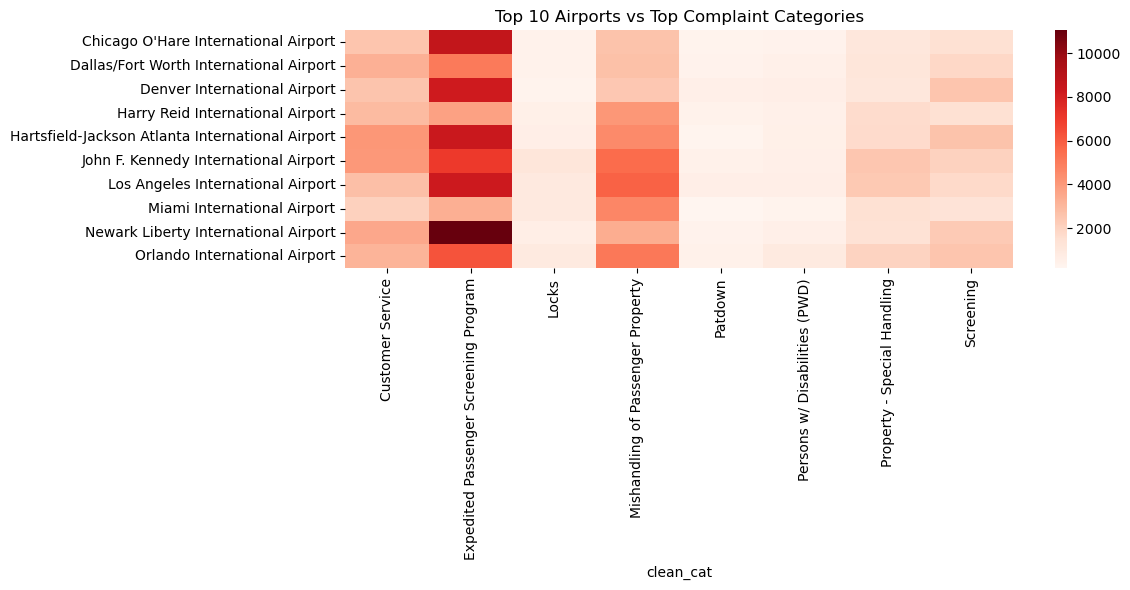

In [4]:
# HEAT MAP (Airport x Category)
heat_data = (
    fact_category_top.groupby(["airport_name", "clean_cat"])["count"]
    .sum()
    .reset_index()
    .pivot(index="airport_name", columns="clean_cat", values="count")
    .fillna(0)
)

plt.figure(figsize=(12,6))
sns.heatmap(heat_data, cmap="Reds")
plt.title("Top 10 Airports vs Top Complaint Categories")
plt.ylabel("")
plt.tight_layout()
plt.show()

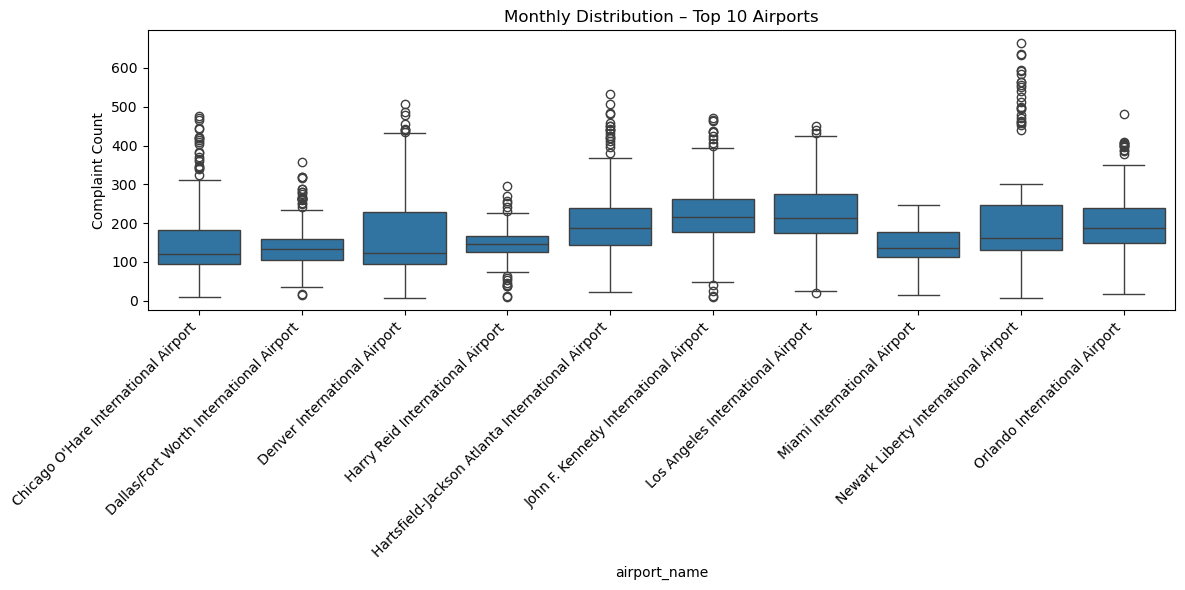

In [5]:
# BOX PLOT
monthly_counts = (
    fact_airport_top.groupby(["airport_name", "year_month"])["count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.boxplot(data=monthly_counts, x="airport_name", y="count")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Complaint Count")
plt.title("Monthly Distribution – Top 10 Airports")
plt.tight_layout()
plt.show()

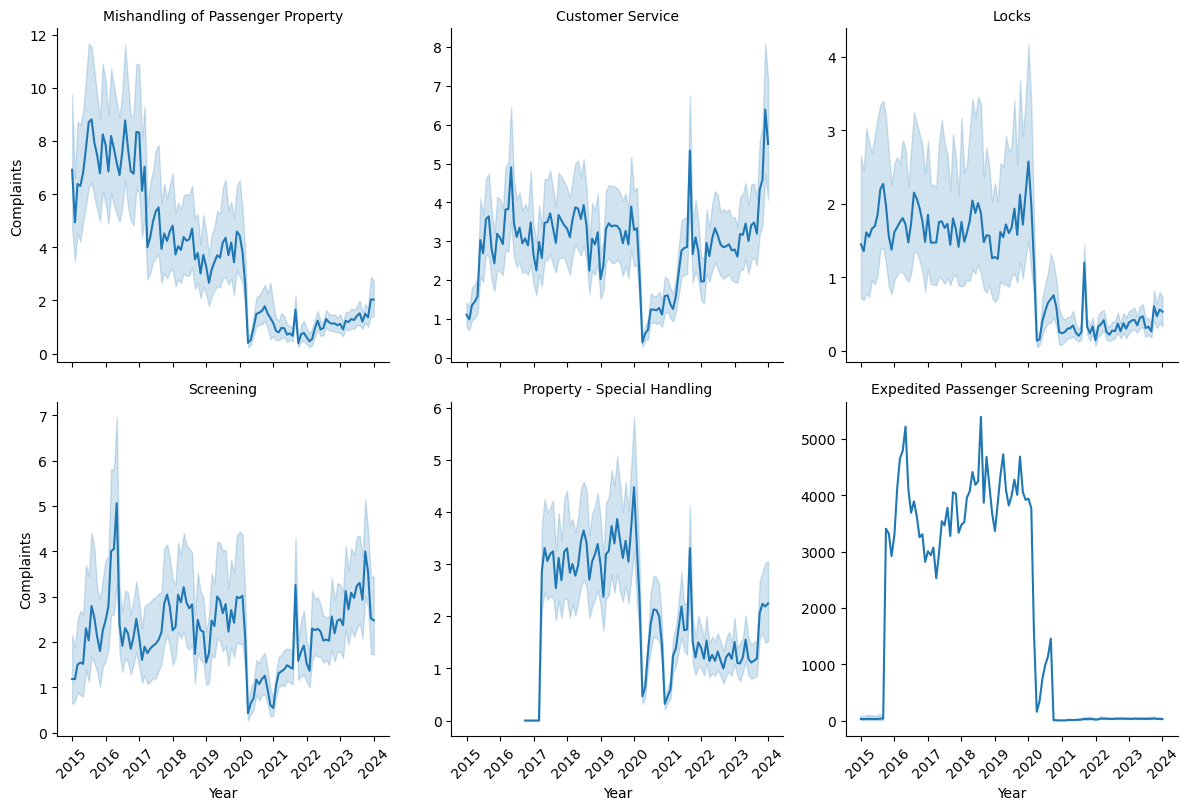

In [6]:
# SMALL MULTIPLES LINE GRAPHS – Top 6 Categories
top6 = (
    fact_category.groupby("category")["count"]
    .sum()
    .nlargest(6)
    .index
)

time_data = fact_category[
    fact_category["category"].isin(top6)
]

g = sns.FacetGrid(
    time_data,
    col="category",
    col_wrap=3,
    sharey=False,
    height=4
)

g.map_dataframe(
    sns.lineplot,
    x="year_month",
    y="count"
)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Complaints")
g.tick_params(axis='x', rotation=45)
plt.show()

C:\Users\Laurie\AppData\Local\Temp\ipykernel_18016\1948584445.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")


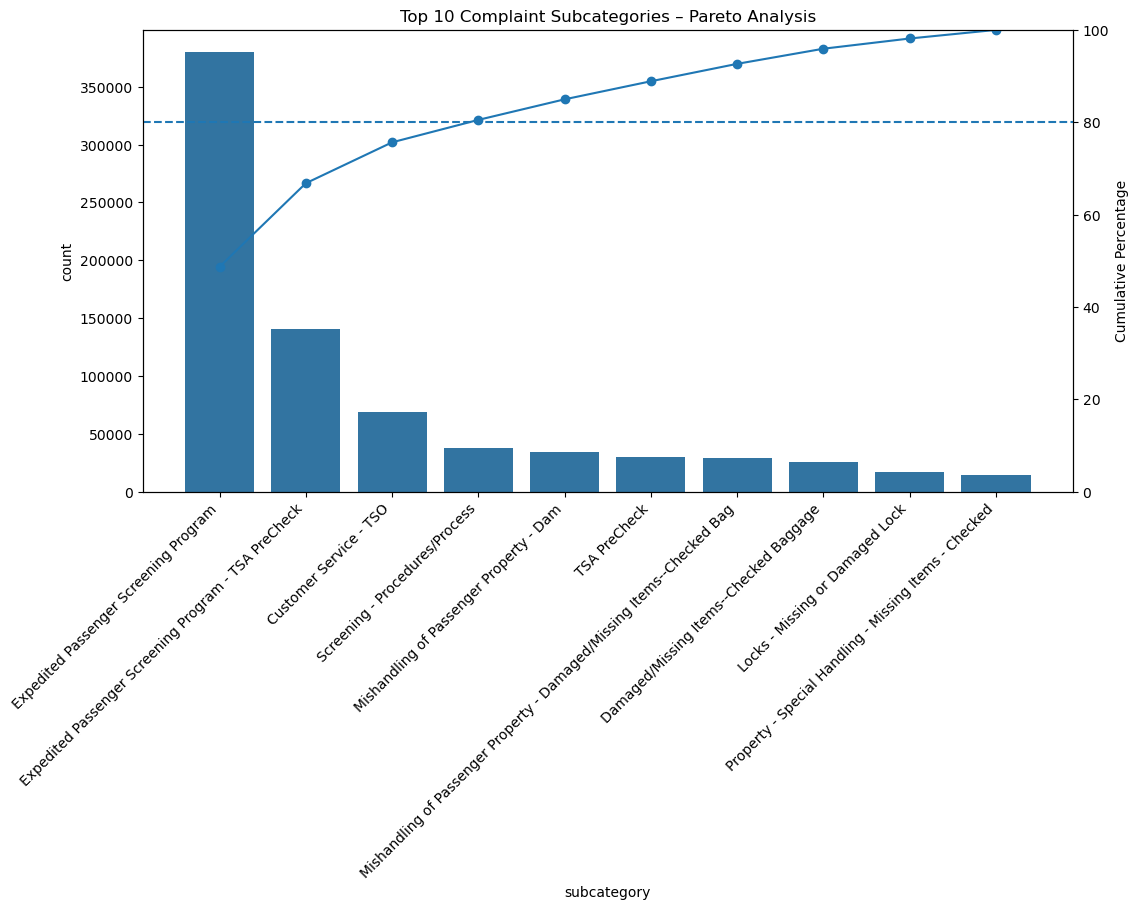

In [7]:
# PARETO CHART ANALYSIS
sub_data = (
    fact_subcategory.groupby("subcategory")["count"]
    .sum()
    .nlargest(10)
    .reset_index()
)

sub_data = sub_data.sort_values("count", ascending=False)
sub_data["cum_pct"] = sub_data["count"].cumsum() / sub_data["count"].sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

sns.barplot(
    data=sub_data,
    x="subcategory",
    y="count",
    ax=ax1
)

ax2 = ax1.twinx()
ax2.plot(
    sub_data["subcategory"],
    sub_data["cum_pct"],
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage")
ax2.set_ylim(0, 100)
ax2.axhline(80, linestyle="--")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
plt.title("Top 10 Complaint Subcategories – Pareto Analysis")
plt.show()

C:\Users\Laurie\AppData\Local\Temp\ipykernel_18016\2265429792.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_category_top["year"] = fact_category_top["year_month"].dt.year


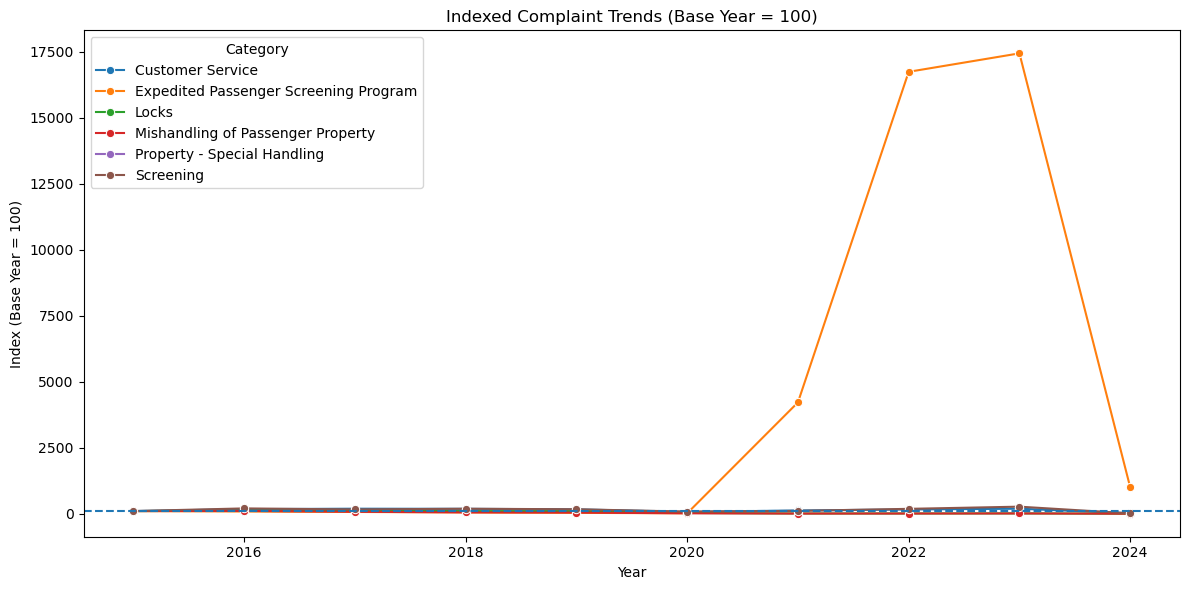

In [8]:
# INDEXED TREND

# Ensure columns are lowercase for consistency
fact_category_top.columns = fact_category_top.columns.str.lower()

# If year does not exist, extract it from year_month
if "year" not in fact_category_top.columns:
    fact_category_top["year"] = fact_category_top["year_month"].dt.year

# Aggregate yearly totals per category
category_year = (
    fact_category_top.groupby(["clean_cat", "year"])["count"]
    .sum()
    .reset_index()
)

# Select top 6 categories by total complaint volume
top6 = (
    category_year.groupby("clean_cat")["count"]
    .sum()
    .nlargest(6)
    .index
)

category_year = category_year[
    category_year["clean_cat"].isin(top6)
].sort_values(["clean_cat", "year"])

# Create indexed values (first year = 100)
category_year["index_value"] = (
    category_year.groupby("clean_cat")["count"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=category_year,
    x="year",
    y="index_value",
    hue="clean_cat",
    marker="o"
)

plt.axhline(100, linestyle="--")
plt.title("Indexed Complaint Trends (Base Year = 100)")
plt.ylabel("Index (Base Year = 100)")
plt.xlabel("Year")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

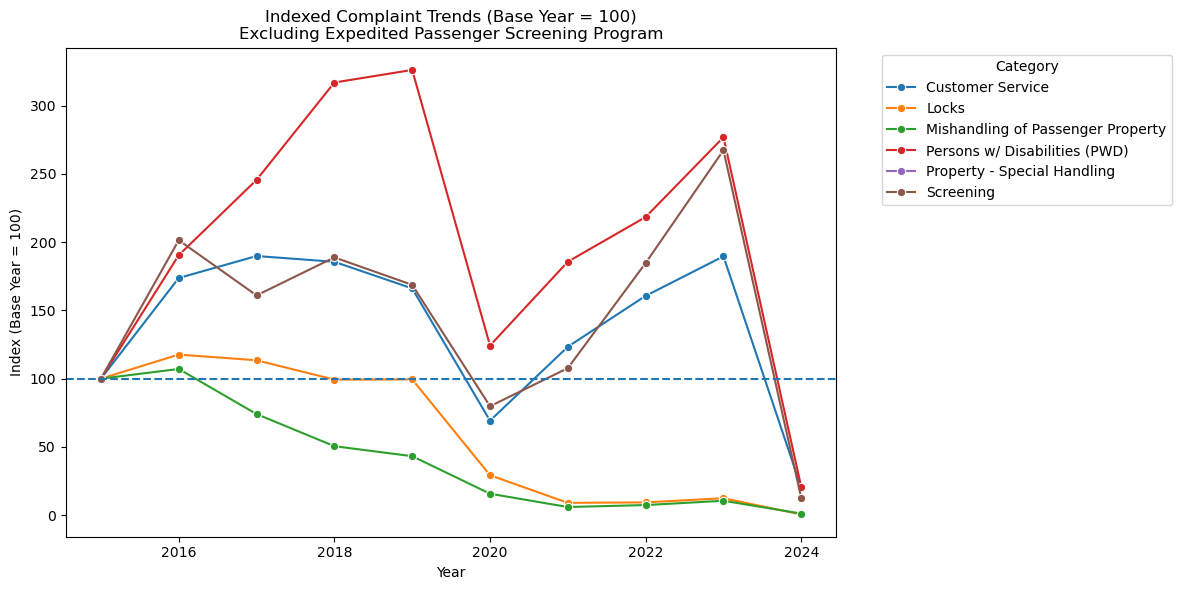

In [9]:
# INDEXED TREND (Excluding Expedited Passenger Screening Program)

# Standardize column names
fact_category_top.columns = fact_category_top.columns.str.lower()

# Ensure year column exists
if "year" not in fact_category_top.columns:
    fact_category_top["year"] = fact_category_top["year_month"].dt.year

# Aggregate yearly totals
category_year = (
    fact_category_top.groupby(["clean_cat", "year"])["count"]
    .sum()
    .reset_index()
)

# Remove Expedited Passenger Screening Program
category_year = category_year[
    category_year["clean_cat"] != "Expedited Passenger Screening Program"
]

# Select top 6 remaining categories by total volume
top6 = (
    category_year.groupby("clean_cat")["count"]
    .sum()
    .nlargest(6)
    .index
)

category_year = category_year[
    category_year["clean_cat"].isin(top6)
].sort_values(["clean_cat", "year"])

# Create indexed value (base year = first available year per category)
category_year["index_value"] = (
    category_year.groupby("clean_cat")["count"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=category_year,
    x="year",
    y="index_value",
    hue="clean_cat",
    marker="o"
)

plt.axhline(100, linestyle="--")
plt.title("Indexed Complaint Trends (Base Year = 100)\nExcluding Expedited Passenger Screening Program")
plt.ylabel("Index (Base Year = 100)")
plt.xlabel("Year")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In order to strenghten the message to the target audience I will create an risk index for ranking that will weigh volume of complaints higher than growth, which will be weighted higher than volitility. This will allow ranking of airports based on current complaint exposure, emerging complaint risk, and complaint volatility.

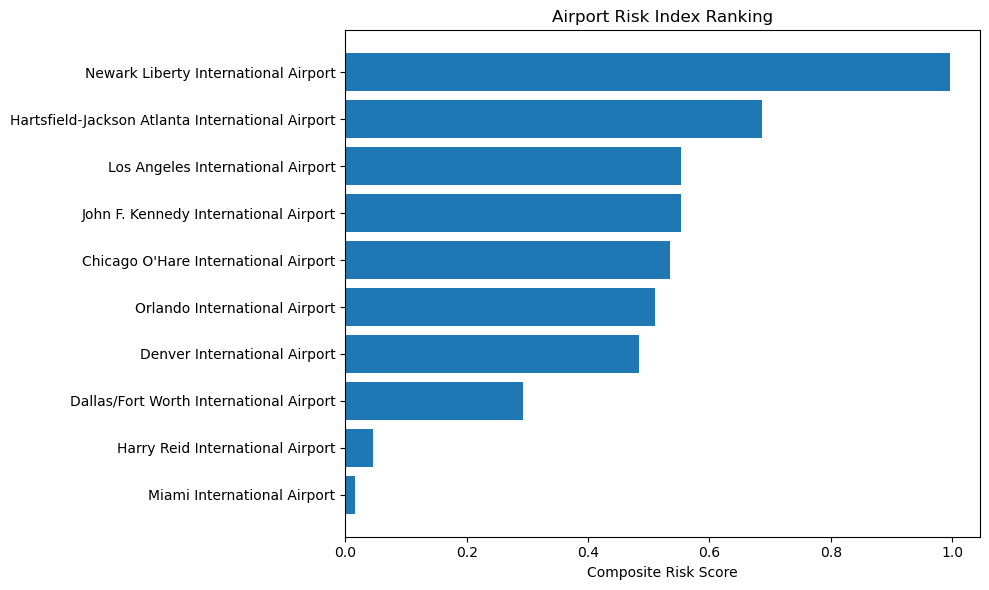

In [10]:
# AIRPORT RISK INDEX

# Airport-Year Aggregation (for Growth)
airport_year = (
    fact_category_top
    .groupby(["airport_name", "year"])["count"]
    .sum()
    .reset_index()
    .sort_values(["airport_name", "year"])
)

# Indexed growth (first year = 100)
airport_year["growth_index"] = (
    airport_year.groupby("airport_name")["count"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

latest_year = airport_year["year"].max()

growth_df = airport_year[
    airport_year["year"] == latest_year
][["airport_name", "growth_index"]]


# Volume Metric
volume_df = (
    fact_category_top
    .groupby("airport_name")["count"]
    .sum()
    .reset_index(name="total_volume")
)


# Volatility Metric (Monthly Std Dev)
airport_month = (
    fact_category_top
    .groupby(["airport_name", "year_month"])["count"]
    .sum()
    .reset_index()
)

volatility_df = (
    airport_month
    .groupby("airport_name")["count"]
    .std()
    .reset_index(name="volatility")
)


# Merge Metrics
risk_df = (
    volume_df
    .merge(growth_df, on="airport_name")
    .merge(volatility_df, on="airport_name")
    .fillna(0)
)


# Min-Max Normalization
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

risk_df["volume_norm"] = min_max(risk_df["total_volume"])
risk_df["growth_norm"] = min_max(risk_df["growth_index"])
risk_df["volatility_norm"] = min_max(risk_df["volatility"])


# Weighted Composite Risk Score
risk_df["risk_score"] = (
    0.4 * risk_df["volume_norm"] +
    0.35 * risk_df["growth_norm"] +
    0.25 * risk_df["volatility_norm"]
)

risk_df = risk_df.sort_values("risk_score", ascending=False)


# Visualization – Horizontal Ranking
top_risk = risk_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_risk["airport_name"], top_risk["risk_score"])
plt.gca().invert_yaxis()

plt.title("Airport Risk Index Ranking")
plt.xlabel("Composite Risk Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

For this data set, the audience was selected to be aviation authorities, airport operations leadership, and safety and compliance teams. With the audiences in mind we aree assuming that they are technically literate in the space, are familiar with operations, and comfortable with regulatory impacts and risk based resource allocation. The goal around these visualizations was to focus on the concentration of complaints and which risk categories we are seeing acceleration to use a indicator of operational stress and potential breakdown and regulatory exposure. These help support the call to action to prioritize audits in high-growth risk categories and at airports with persistent complaint concentration and to reallocate safety oversight in alignment with these identified trends. These indicate that while Expedited Passenger Screening experienced an outlying shock it is still one of the categories of increased complaints and risks that would be a target for focus as seen in the pareto analysis and indexed complaint trends. The heatmap and Risk Index Ranking also support Newark Liberty, Hartsfield-Jackson Atlanta, and Los Angeles airports as elevated locations for complaint clustering in screening and customer service which may indicate operational concerns. Similarly, this is mirrored in the box plots for Hartsfield and Newark further supporting high volatility which may indicate operational concerns. The visualizations were kept in a nuetral palette to reduce unnescessary alarm and keep consistent category mapping with exception of the heatmap to show for intensity. Layouts were kept with a narrow focus on high impact airports and categories and to keep cognitive overload. Ethical consideration for the data is grounded in data credibility from federal complaint data with no personal identifiable information and kept at a aggregated operational level. There were data transformations to agregate to yearly totals for trend analysis and indexed based on earliest available year for comparison. Data with missing categories or airports were also excluded which is crucial for the audience to understand. It is also important that while these complaints are used to be indicators or risk and operational concerns these are only indicators and should not be used to state airports were in noncompliance or had violations.